# Movie Success Prediction - Machine Learning Notebook

This notebook builds machine learning models to predict whether a movie is financially successful using the cleaned TMDB movie dataset. A movie is considered successful if its revenue is greater than its budget. The notebook includes feature selection, categorical encoding, train/test splitting, model training, evaluation, and comparison of multiple models.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [14]:
df = pd.read_csv("../Datasets/clean_movies.csv")

df.head()

,id,title,genres,keywords,cast,budget,revenue,runtime,vote_average,vote_count,popularity,release_date,original_language,director,release_year,success,profit,roi,main_genre,main_actor
0,19995,Avatar,"['Action', 'Adventure', 'Fantasy', 'Science Fi...","['culture clash', 'future', 'space war', 'spac...","['Sam Worthington', 'Zoe Saldana', 'Sigourney ...",237000000,2787965087,162.0,7.2,11800,150.437577,2009-12-10,en,James Cameron,2009,True,2550965087,10.763566,Action,Sam Worthington
1,285,Pirates of the Caribbean: At World's End,"['Adventure', 'Fantasy', 'Action']","['ocean', 'drug abuse', 'exotic island', 'east...","['Johnny Depp', 'Orlando Bloom', 'Keira Knight...",300000000,961000000,169.0,6.9,4500,139.082615,2007-05-19,en,Gore Verbinski,2007,True,661000000,2.203333,Adventure,Johnny Depp
2,206647,Spectre,"['Action', 'Adventure', 'Crime']","['spy', 'based on novel', 'secret agent', 'seq...","['Daniel Craig', 'Christoph Waltz', 'Léa Seydo...",245000000,880674609,148.0,6.3,4466,107.376788,2015-10-26,en,Sam Mendes,2015,True,635674609,2.594590,Action,Daniel Craig
3,49026,The Dark Knight Rises,"['Action', 'Crime', 'Drama', 'Thriller']","['dc comics', 'crime fighter', 'terrorist', 's...","['Christian Bale', 'Michael Caine', 'Gary Oldm...",250000000,1084939099,165.0,7.6,9106,112.312950,2012-07-16,en,Christopher Nolan,2012,True,834939099,3.339756,Action,Christian Bale
4,49529,John Carter,"['Action', 'Adventure', 'Science Fiction']","['based on novel', 'mars', 'medallion', 'space...","['Taylor Kitsch', 'Lynn Collins', 'Samantha Mo...",260000000,284139100,132.0,6.1,2124,43.926995,2012-03-07,en,Andrew Stanton,2012,True,24139100,0.092843,Action,Taylor Kitsch


In [15]:
df.shape

(3227, 20)

In [17]:
df["success"].value_counts()

success
True     2438
False     789
Name: count, dtype: int64

In [18]:
df["success"].value_counts(normalize=True)

success
True     0.7555
False    0.2445
Name: proportion, dtype: float64

The target variable is `success`, which is True when a movie's revenue is greater than its budget. The dataset contains more successful movies than unsuccessful movies, so model evaluation should include precision, recall, F1-score, and a confusion matrix rather than accuracy alone.

The target variable is `success`, which is True when a movie's revenue is greater than its budget. The dataset contains more successful movies than unsuccessful movies, so model evaluation should include precision, recall, F1-score, and a confusion matrix rather than accuracy alone.

In [19]:
features = [
    "budget",
    "runtime",
    "vote_average",
    "vote_count",
    "popularity",
    "release_year",
    "main_genre",
    "original_language"
]

X = df[features]
y = df["success"].astype(int)

X.head()

,budget,runtime,vote_average,vote_count,popularity,release_year,main_genre,original_language
0,237000000,162.0,7.2,11800,150.437577,2009,Action,en
1,300000000,169.0,6.9,4500,139.082615,2007,Adventure,en
2,245000000,148.0,6.3,4466,107.376788,2015,Action,en
3,250000000,165.0,7.6,9106,112.312950,2012,Action,en
4,260000000,132.0,6.1,2124,43.926995,2012,Action,en


In [20]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: success, dtype: int64

The selected features include budget, runtime, rating-related variables, popularity, release year, genre, and original language. Revenue, profit, and ROI were excluded because they would create data leakage by directly revealing whether a movie was successful.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (2581, 8)
Testing set size: (646, 8)


In [22]:
numeric_features = [
    "budget",
    "runtime",
    "vote_average",
    "vote_count",
    "popularity",
    "release_year"
]

categorical_features = [
    "main_genre",
    "original_language"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [23]:
def evaluate_model(model_name, model, X_test, y_test):
    predictions = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    
    print(f"Model: {model_name}")
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1 Score:", round(f1, 4))
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))
    
    cm = confusion_matrix(y_test, predictions)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

Model: Logistic Regression
Accuracy: 0.7105
Precision: 0.9288
Recall: 0.668
F1 Score: 0.7771

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.84      0.59       158
           1       0.93      0.67      0.78       488

    accuracy                           0.71       646
   macro avg       0.69      0.75      0.68       646
weighted avg       0.81      0.71      0.73       646



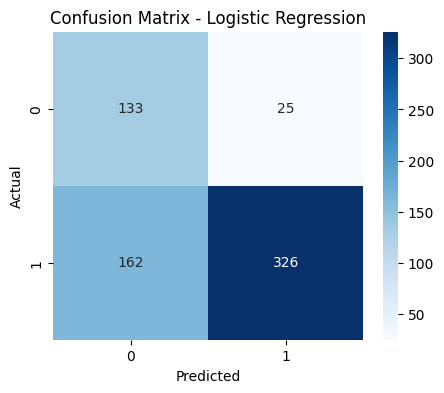

In [24]:
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_reg_model.fit(X_train, y_train)

log_reg_results = evaluate_model(
    "Logistic Regression",
    log_reg_model,
    X_test,
    y_test
)

Model: Decision Tree
Accuracy: 0.7136
Precision: 0.9084
Recall: 0.6906
F1 Score: 0.7846

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.78      0.57       158
           1       0.91      0.69      0.78       488

    accuracy                           0.71       646
   macro avg       0.68      0.74      0.68       646
weighted avg       0.80      0.71      0.73       646



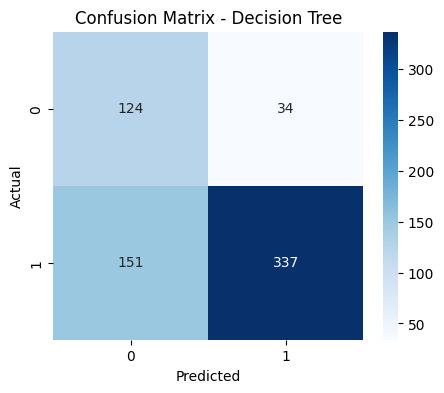

In [25]:
decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=6,
        class_weight="balanced"
    ))
])

decision_tree_model.fit(X_train, y_train)

decision_tree_results = evaluate_model(
    "Decision Tree",
    decision_tree_model,
    X_test,
    y_test
)

Model: Random Forest
Accuracy: 0.7693
Precision: 0.8988
Recall: 0.7828
F1 Score: 0.8368

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.73      0.61       158
           1       0.90      0.78      0.84       488

    accuracy                           0.77       646
   macro avg       0.71      0.76      0.72       646
weighted avg       0.81      0.77      0.78       646



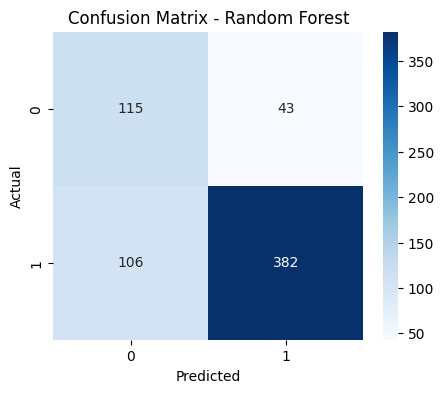

In [26]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        max_depth=10,
        class_weight="balanced"
    ))
])

random_forest_model.fit(X_train, y_train)

random_forest_results = evaluate_model(
    "Random Forest",
    random_forest_model,
    X_test,
    y_test
)

In [27]:
results_df = pd.DataFrame([
    log_reg_results,
    decision_tree_results,
    random_forest_results
])

results_df

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.710526,0.928775,0.668033,0.777116
1,Decision Tree,0.713622,0.908356,0.690574,0.784633
2,Random Forest,0.769350,0.898824,0.782787,0.836802


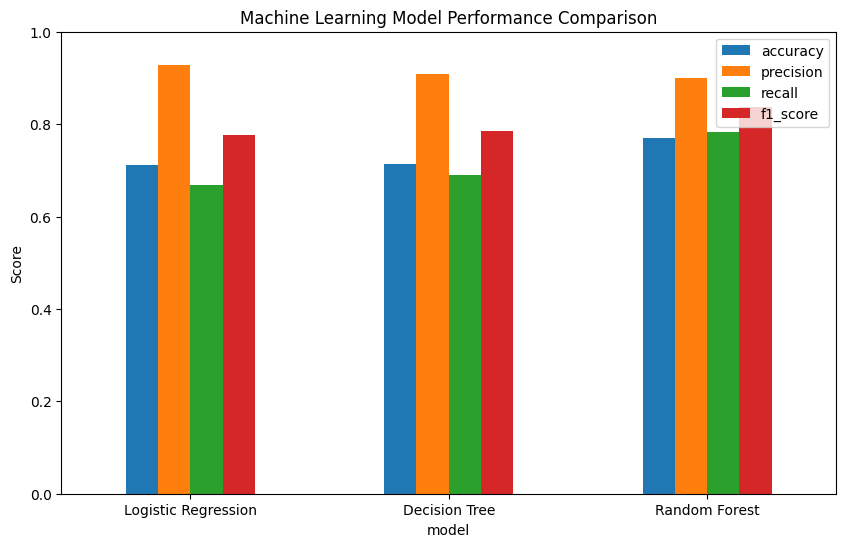

In [28]:
results_df.set_index("model")[["accuracy", "precision", "recall", "f1_score"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

The model comparison shows how Logistic Regression, Decision Tree, and Random Forest performed on the same test set. Since the dataset has more successful movies than unsuccessful movies, F1-score is especially useful because it balances precision and recall.

In [29]:
rf_classifier = random_forest_model.named_steps["classifier"]
preprocessor_fitted = random_forest_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()
importances = rf_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(15)

,feature,importance
3,num__vote_count,0.323825
4,num__popularity,0.251680
2,num__vote_average,0.095098
5,num__release_year,0.089087
0,num__budget,0.087913
1,num__runtime,0.058258
16,cat__main_genre_Horror,0.014329
12,cat__main_genre_Drama,0.010567
9,cat__main_genre_Comedy,0.008534
6,cat__main_genre_Action,0.007798


In [ ]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The feature importance chart shows which variables were most useful for the Random Forest model. Features such as budget, popularity, vote count, and vote average may strongly influence whether a movie is predicted as successful.

In [31]:
os.makedirs("../ML_Results", exist_ok=True)

results_df.to_csv("../ML_Results/model_performance.csv", index=False)
feature_importance_df.to_csv("../ML_Results/random_forest_feature_importance.csv", index=False)

print("Machine learning results saved successfully.")

Machine learning results saved successfully.


In [32]:
results_df

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.710526,0.928775,0.668033,0.777116
1,Decision Tree,0.713622,0.908356,0.690574,0.784633
2,Random Forest,0.769350,0.898824,0.782787,0.836802


The machine learning results showed that the Random Forest model performed best overall, with an accuracy of 76.9% and an F1-score of 0.837. Logistic Regression and Decision Tree performed similarly, with accuracies around 71%, but their F1-scores were lower than Random Forest. Since the dataset contains more successful movies than unsuccessful movies, F1-score is especially important because it balances precision and recall. Random Forest achieved the best balance, making it the strongest model for predicting movie success in this project.